# Phase 2-4: Exploratory Data Analysis

## Setup & Data Loading
Import core libraries and load the **cleaned** dataset produced in Phase 1
(`data/processed/retail_sales_cleaned.csv`). All analysis below assumes the
data has already passed cleaning and validation.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.plots import *

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("../data/processed/retail_sales_cleaned.csv", parse_dates = ['order_date'])

# Retail Sales Analysis — Phase 2: Exploratory Analysis

This notebook explores the **cleaned retail sales dataset** produced in Phase 1. Using pandas aggregations and grouping, we surface patterns in revenue, regional performance, payment behavior, discount sensitivity, temporal trends, and customer demographics.

All analysis runs on `retail_sales_cleaned.csv`, the analysis-ready output of the Phase 1 pipeline (deduplicated, imputed, and feature-engineered). Note that `customer_age`, `customer_rating`, and `payment_method` contain imputed values where the original data was missing; aggregate results therefore include these estimated values alongside observed ones.

--- 

## 1. Top 5 Best-Selling Products by Total Revenue

In [3]:
display(df.groupby('product', as_index = False).agg(
    total_revenue = ('total_price', 'sum')).sort_values('total_revenue',ascending = False).reset_index(
        drop = True).iloc[:5])

,product,total_revenue
0,Laptop,498131.86
1,Smartphone,325882.74
2,Tablet,186874.04
3,Bicycle,140500.62
4,Smartwatch,106473.64


## 2. Regional Revenue: Highest and Lowest

In [4]:
regional_revenue = df.groupby('region')['total_price'].sum()
print(f'Highest Revenue Generator Region: {regional_revenue.idxmax()}')
print(f'Lowest Revenue Generator Region: {regional_revenue.idxmin()}')

Highest Revenue Generator Region: West
Lowest Revenue Generator Region: Central


## 3. Average Order Value per Payment Method

In [6]:
display(df.groupby('payment_method', as_index = False).agg(
    avg_order_value = ('total_price', 'mean')).sort_values('avg_order_value').reset_index(drop = True))

,payment_method,avg_order_value
0,PayPal,328.903614
1,Cash,358.103222
2,Credit Card,371.287609
3,Debit Card,376.942995
4,Gift Card,427.418214


## 4. Relationship Between Discount and Customer Rating

In [7]:
display(df.groupby('discount_pct', as_index = False).agg(
    avg_customer_rating = ('customer_rating', 'mean')).sort_values('discount_pct').reset_index(drop = True))

,discount_pct,avg_customer_rating
0,0,3.669246
1,5,3.746853
2,10,3.825899
3,15,3.836761
4,20,4.018817


### Summary: Discount Percentage vs. Customer Rating

The data shows a clear **positive trend**: as discounts go up, customer ratings also go up across every single level:

* **0% Discount:** 3.67 Stars
* **5% Discount:** 3.75 Stars
* **10% Discount:** 3.83 Stars
* **15% Discount:** 3.84 Stars
* **20% Discount:** 4.02 Stars

#### Key Takeaway
Customers give higher ratings when they get bigger discounts. The biggest jump happens at the **20% discount level**, where the average rating climbs above 4.0 stars—about **0.35 stars higher** than items bought at full price.

---

## 5. Peak Month and Busiest Weekday

In [8]:
peak_month = df.groupby('order_month')['total_price'].sum().idxmax()
print(f'The month with the highest total sales: {peak_month}')

peak_day = df.groupby('order_weekday')['order_id'].count().idxmax()
print(f'The day with the highest total orders: {peak_day}')

The month with the highest total sales: September
The day with the highest total orders: Thursday


## 6. Spending by Age Group

In [9]:
df['age_group'] = pd.cut(df['customer_age'], bins = [17,25,35,45,60,75], 
                         labels = ["18-25", "26-35", "36-45", "46-60", "60+"])

peak_group_age = df.groupby('age_group', observed = True)['total_price'].mean().idxmax()

print(f'The group age which spends most on average: {peak_group_age}')

The group age which spends most on average: 18-25


# Retail Sales Analysis - Phase 3: Visualization Dashboard

With the data cleaned (Phase 1) and the core business questions answered (Phase 2),
we now move into **visual storytelling**. The goal of this phase is to translate our
tabular findings into charts that surface patterns at a glance — trends, distributions,
proportions, and outliers that are hard to read from raw numbers.

**Tasks in this phase:**

1. **Bar chart** — total revenue by category.
2. **Line chart** — total monthly revenue over time (2023–2024 trend).
3. **Pie chart** — share of orders by payment method.
4. **Horizontal bar chart** — top 10 products by total quantity sold.
5. **Histogram** — distribution of `customer_age`.
6. **Boxplot** — `total_price` by region, highlighting outliers.
7. **Scatter / strip plot** — `discount_pct` vs `customer_rating` (with jitter,
   since both axes hold repeating discrete values).
8. **Grouped bar chart** — revenue by region, broken down by category.

**Bonus challenge:** rather than rendering these as eight standalone figures, we
combine them into a **single consolidated dashboard** using `plt.subplots()` on a
4×2 grid — a layout that reads like an executive summary panel.

All charts are built on the cleaned dataset (`retail_sales_cleaned.csv`)

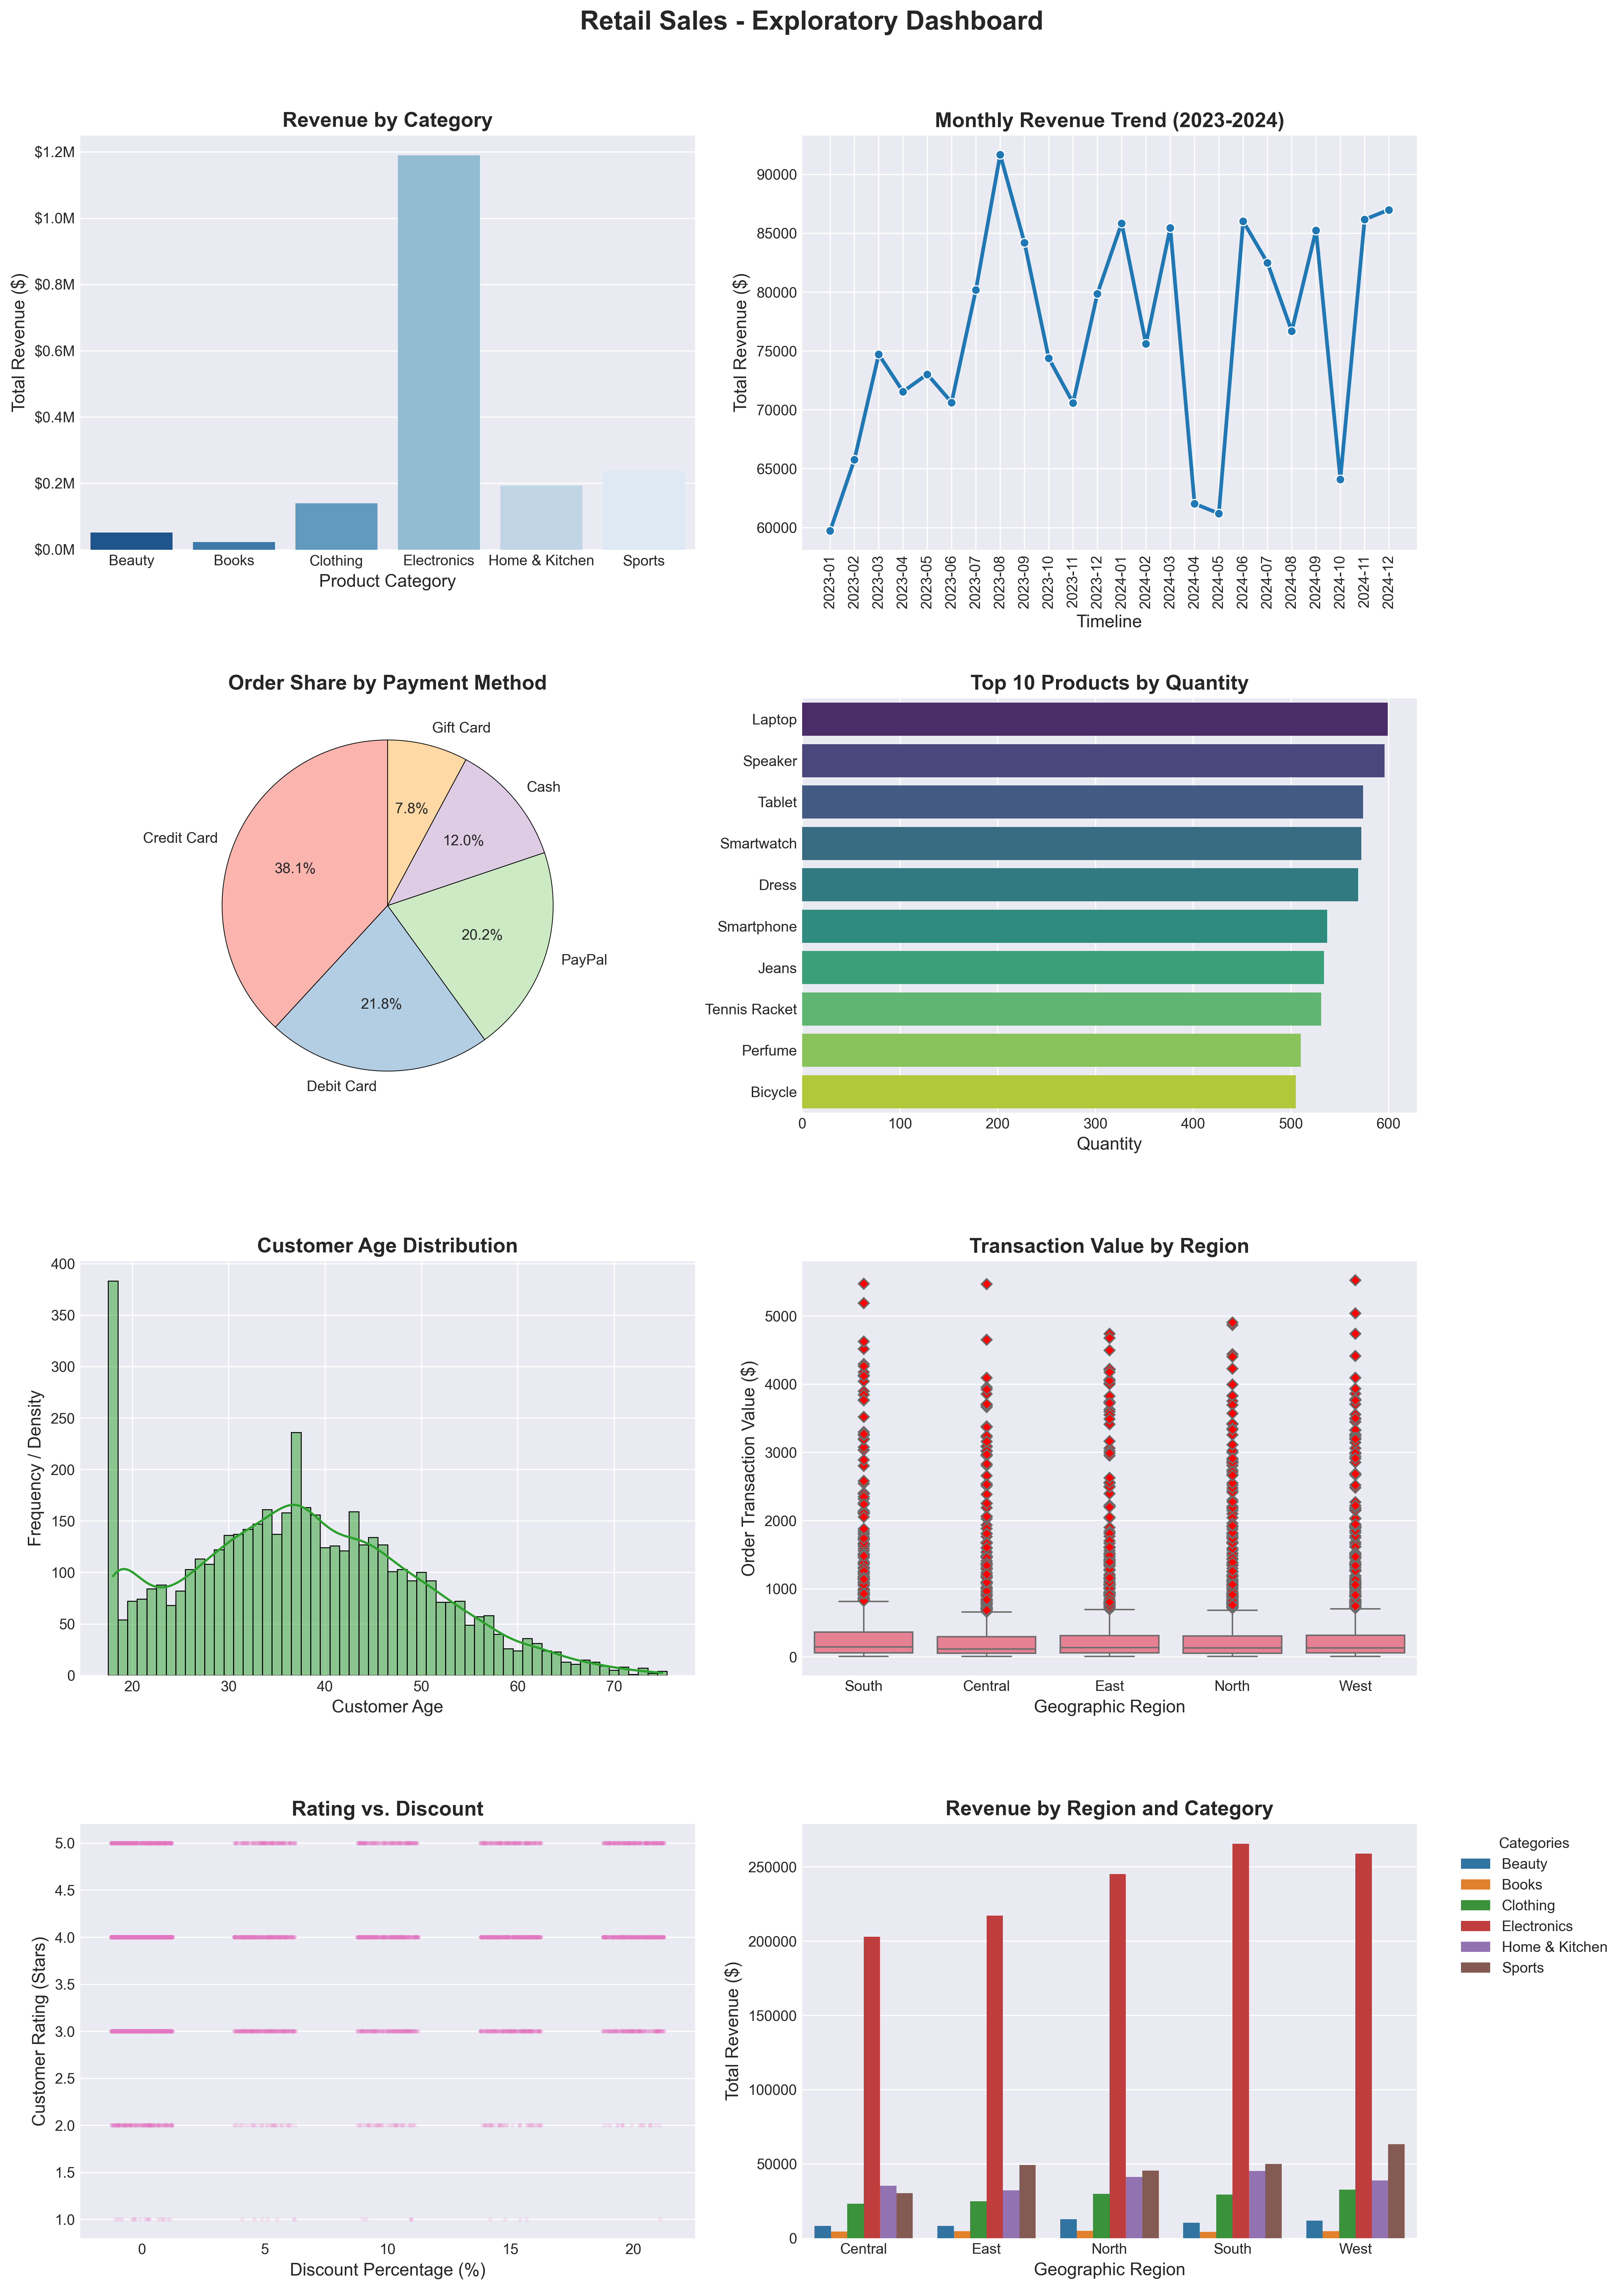

In [10]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (16, 22), dpi = 300)

plot_revenue_by_category(df, ax[0][0])
plot_monthly_revenue_trend(df, ax[0][1])
plot_payment_method_share(df, ax[1][0])
plot_top_products_by_quantity(df, ax[1][1])
plot_customer_age_distribution(df, ax[2][0])
plot_transaction_value_by_region(df, ax[2][1])
plot_rating_vs_discount(df, ax[3][0])
plot_revenue_by_region_and_category(df, ax[3][1])

fig.suptitle('Retail Sales - Exploratory Dashboard', fontsize = 18, fontweight = 'bold', y = 0.995)
fig.tight_layout(pad = 3.0, h_pad = 3.0, w_pad = 2.0)
fig.savefig('../reports/figures/eda_dashboard.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Retail Sales Analysis - Phase 4: Bonus Challenges

With the core analysis complete and the dashboard built, we now tackle **bonus challenges** 
that extend the project's depth. These tasks demonstrate advanced aggregation techniques, 
time-series smoothing, modular code design, and dataset export for future use.

**Tasks in this phase:**

1. **Customer Value Table** — aggregate total spend and order count per customer, then 
   rank the top 10 customers by revenue contribution.
2. **Rolling Average Overlay** — add a 7-day and 30-day moving average line on top of 
   the monthly revenue trend chart to smooth short-term volatility.
3. **Consolidated Dashboard** — already completed in Phase 3 (4×2 subplot grid).
4. **Export Cleaned Dataset** — already completed; `retail_sales_clean.csv` saved 
   during Phase 1.

--- 

## Customer Value Table

**Objective:** Identify high-value customers by aggregating their transaction history.

For each unique `customer_id`, we compute:
- **Total Spend** — sum of all `total_price` values across their orders
- **Order Count** — number of distinct orders they placed

The result is sorted by total spend (descending) to surface the **top 10 customers** — 
the most valuable segment for retention, loyalty programs, or targeted marketing.

This table answers: *Who are our most profitable customers?*

In [11]:
customer_value_table = df.groupby('customer_id', as_index = False).agg(total_spend = ('total_price', 'sum'),
                        order_count = ('order_id', 'count')).sort_values('total_spend', ascending = False).reset_index(drop = True)

print("Top 10 Customers by Total Spend:")
display(customer_value_table.head(10))

Top 10 Customers by Total Spend:


,customer_id,total_spend,order_count
0,10718,9664.36,3
1,10529,9216.87,5
2,10383,8983.34,5
3,11197,8602.46,8
4,10787,8423.60,9
5,10733,7590.60,7
6,10948,7543.58,5
7,10103,7436.51,8
8,10944,7427.68,7
9,10246,7188.63,4


## Monthly Revenue with Rolling Average

**Objective:** Overlay a smoothed trend line on the monthly revenue chart to identify underlying patterns obscured by month-to-month volatility.

We compute a **30-day rolling average** on the daily revenue data and display it on a secondary y-axis using `twinx()`, allowing both series to share a common time axis while respecting their vastly different scales.

The rolling average reveals:
- **Seasonal trends** — sustained upward or downward movements across quarters
- **Outliers** — months whose revenue deviates significantly from the smoothed trajectory

This visualization answers: *Beyond the noise, what is the true direction of our revenue?*

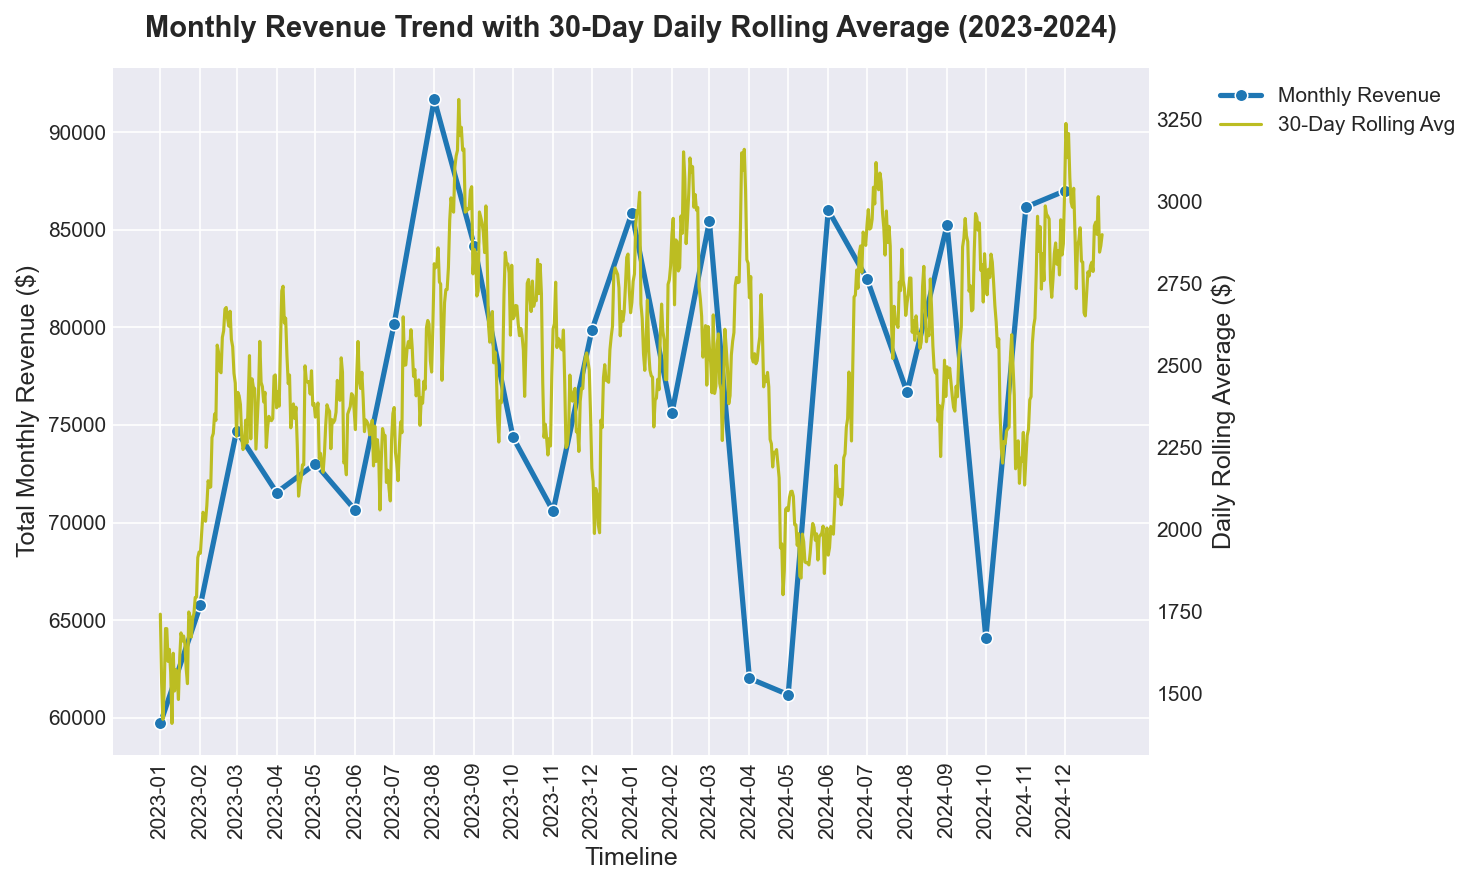

In [14]:
fig, monthly_ax = plt.subplots(figsize = (10, 6), dpi = 150)

plot_monthly_revenue_with_rolling(df, monthly_ax)

fig.tight_layout()
plt.show()